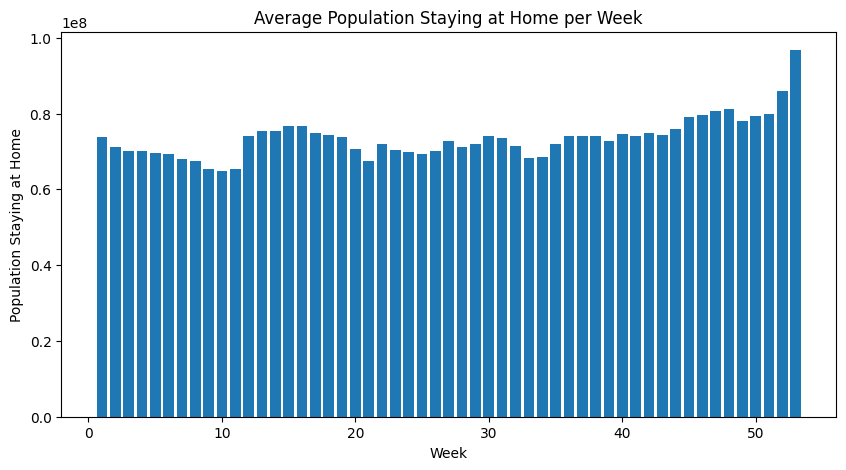

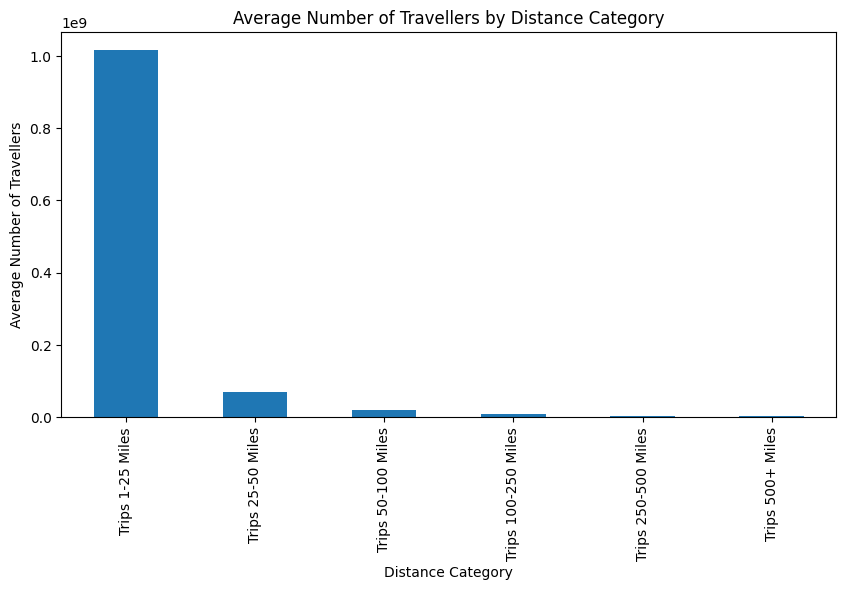

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# load datasets
td = pd.read_csv("Trips_by_Distance.csv", parse_dates=["Date"])
tf = pd.read_csv("Trips_Full Data.csv", parse_dates=["Date"])

# keep only national level data
td = td[td["Level"] == "National"]
tf = tf[tf["Level"] == "National"]

# create week column
td["Week"] = td["Date"].dt.isocalendar().week

# -------------------------
# 1. Average people staying at home per week
# -------------------------
weekly_home = td.groupby("Week")["Population Staying at Home"].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.bar(weekly_home["Week"], weekly_home["Population Staying at Home"])
plt.xlabel("Week")
plt.ylabel("Population Staying at Home")
plt.title("Average Population Staying at Home per Week")
plt.show()

# -------------------------
# 2. Average travellers by distance category
# -------------------------
distance_means = tf[[
    "Trips 1-25 Miles",
    "Trips 25-50 Miles",
    "Trips 50-100 Miles",
    "Trips 100-250 Miles",
    "Trips 250-500 Miles",
    "Trips 500+ Miles"
]].mean()

plt.figure(figsize=(10, 5))
distance_means.plot(kind="bar")
plt.xlabel("Distance Category")
plt.ylabel("Average Number of Travellers")
plt.title("Average Number of Travellers by Distance Category")
plt.show()